<a href="https://colab.research.google.com/github/springboardmentor1077k-prog/Vision-Extract-Isolation/blob/Suryansh_G/Data_Augmentation_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Data Augmentation Pipeline in Google Colab
This notebook demonstrates how to apply a custom data augmentation pipeline using **Albumentations** and visualize the results.

In [2]:
# Completely remove all related packages
!pip uninstall -y albumentations albucore
!pip install --force-reinstall albumentations==1.3.1  # Older stable version

Found existing installation: albumentations 1.4.10
Uninstalling albumentations-1.4.10:
  Successfully uninstalled albumentations-1.4.10
Found existing installation: albucore 0.0.33
Uninstalling albucore-0.0.33:
  Successfully uninstalled albucore-0.0.33
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
  Using cached opencv_python_headless-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 20.6 MB/s 

In [9]:
# STEP 2 — Import libraries
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import os


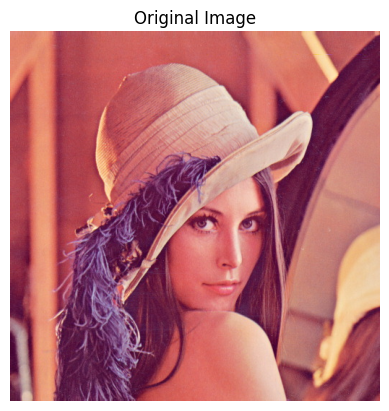

In [11]:
# STEP 3 — Load an image
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg -O image.jpg

image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [12]:
# STEP 4 — Define Augmentation Pipeline
transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=25, p=0.5)
])

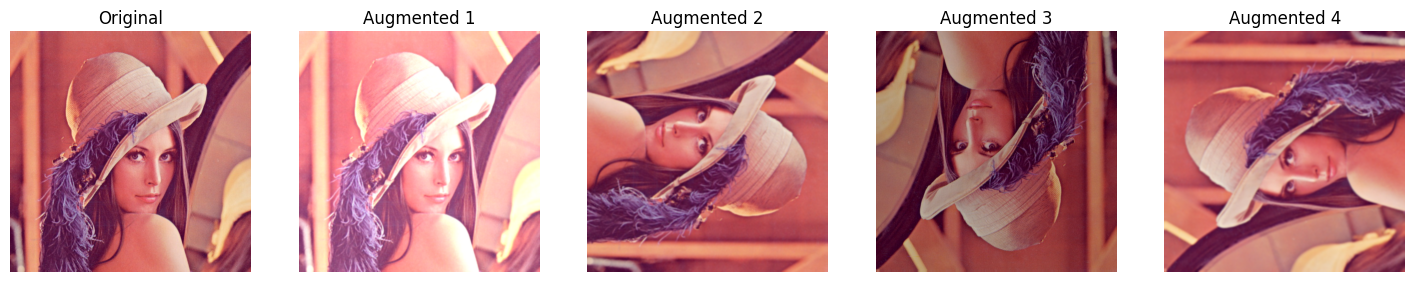

In [13]:
# STEP 5 — Apply Augmentations and Visualize
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(4):
    augmented = transform(image=image)['image']
    axes[i+1].imshow(augmented)
    axes[i+1].set_title(f"Augmented {i+1}")
    axes[i+1].axis("off")

plt.show()